In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

### 5-Fold Cross-Validation Accuracy: 0.9596 (+/- 0.0363)

### LOGISTIC REGRESSION COEFFICIENTS (Sorted)
                                      Feature  Coefficient
13                                    TechLev     1.919062
15                                   InnoCont     1.623294
11                                      AIUse     1.492410
17                                  PerfScore     1.264967
16                                 TrainHours     1.238124
12                       SpecialProjectsCount     1.015185
7                                      AIConf     0.935656
9                                    Feedback     0.866259
4                                    ProjColl     0.547960
14                                     ManPos     0.475384
8                                     PsySafe     0.418424
27                             RaceDesc_White     0.392563
31                   RecruitmentSource_Indeed     0.376775
22                        MaritalDesc_Widowed     0.275587
10        

/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_89877/4069584442.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)


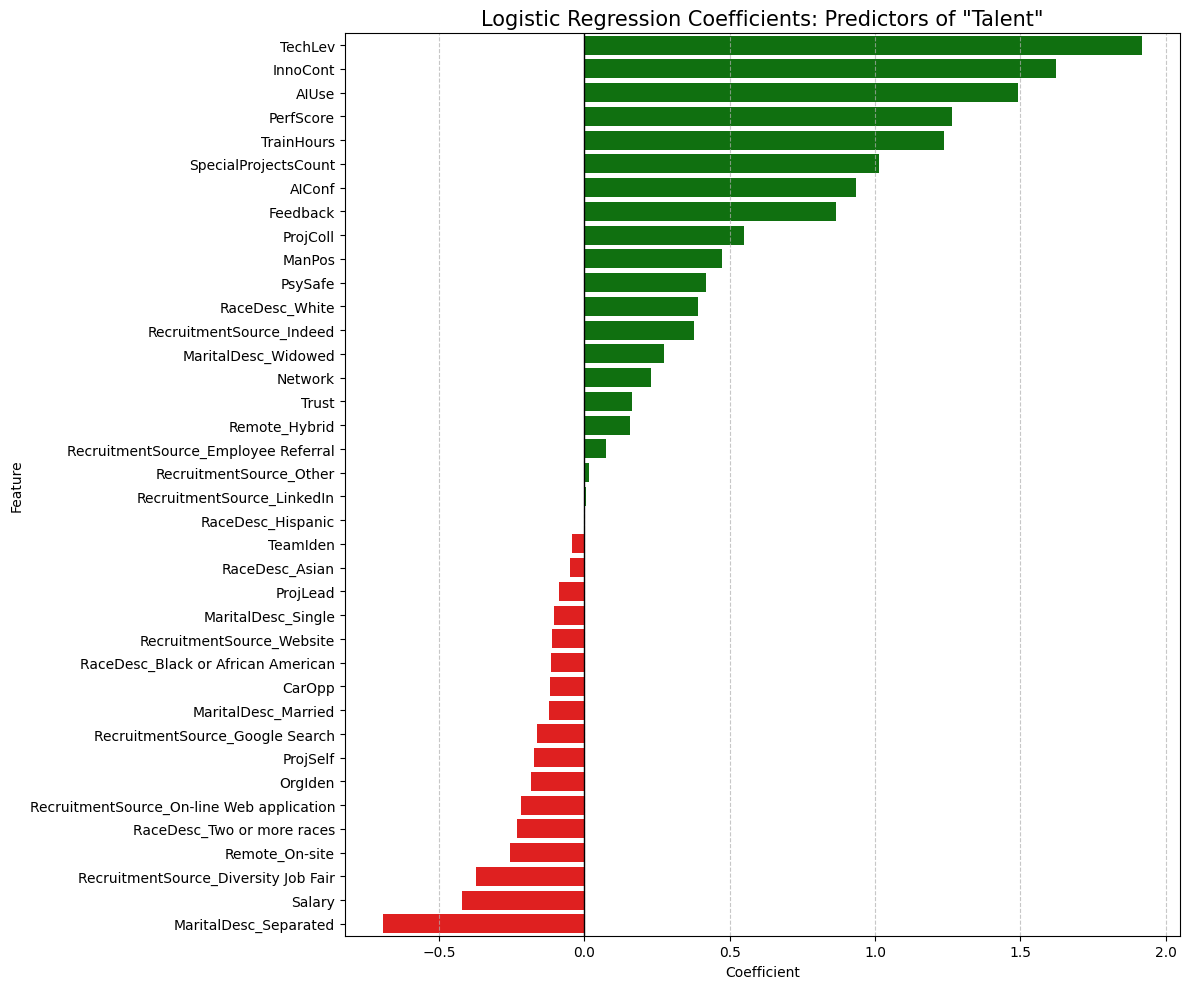

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Define features
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours', 'PerfScore', 'Salary', 
    'MaritalDesc', 'RaceDesc', 'RecruitmentSource', 'Remote'
]

# 2. Data Preparation
# Target: is_talent
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_talent']

# 3. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

# 4. Build Logistic Regression Pipeline
# Added StandardScaler: essential for Logistic Regression to compare coefficients fairly
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        random_state=42
    ))
])

# 5. Cross-Validation (CV=5)
# This tests the model's stability on 5 different folds of the training data
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5)

# 6. Train the Model
model_pipeline.fit(X_train, y_train)

# 7. Extract and Order Coefficients
# We access the classifier from the pipeline to get weights
coefs = model_pipeline.named_steps['classifier'].coef_[0]
feature_names = X.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

# --- FINAL OUTPUTS ---

print(f"### 5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n### LOGISTIC REGRESSION COEFFICIENTS (Sorted)")
print(coef_df)

# Evaluation on separate Test Set
y_test_pred = model_pipeline.predict(X_test)
print("\n### TEST SET CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred))

# 8. Visualization of Coefficients
plt.figure(figsize=(12, 10))
# Using a diverging color palette to highlight positive vs negative
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)

plt.title('Logistic Regression Coefficients: Predictors of "Talent"', fontsize=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Add a center line at 0
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5-Fold CV Accuracy: 0.8643

### TOP PREDICTORS OF TURNOVER (Positive = Higher Risk of Leaving)
                                      Feature  Coefficient
17                                  PerfScore     0.835498
15                                   InnoCont     0.608995
11                                      AIUse     0.485219
33  RecruitmentSource_On-line Web application     0.420763
37                             Remote_On-site     0.398290
36                              Remote_Hybrid     0.344813
10                                    Network     0.329143
16                                 TrainHours     0.318287
30            RecruitmentSource_Google Search     0.233437
27                             RaceDesc_White     0.205264

### TOP 5 ACTIVE EMPLOYEES AT RISK
     Employee_Index  Flight_Risk_Probability
15               23                 0.988888
50               69                 0.970494
195             288                 0.954268
80              111                 

/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_89877/895728963.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette=colors)


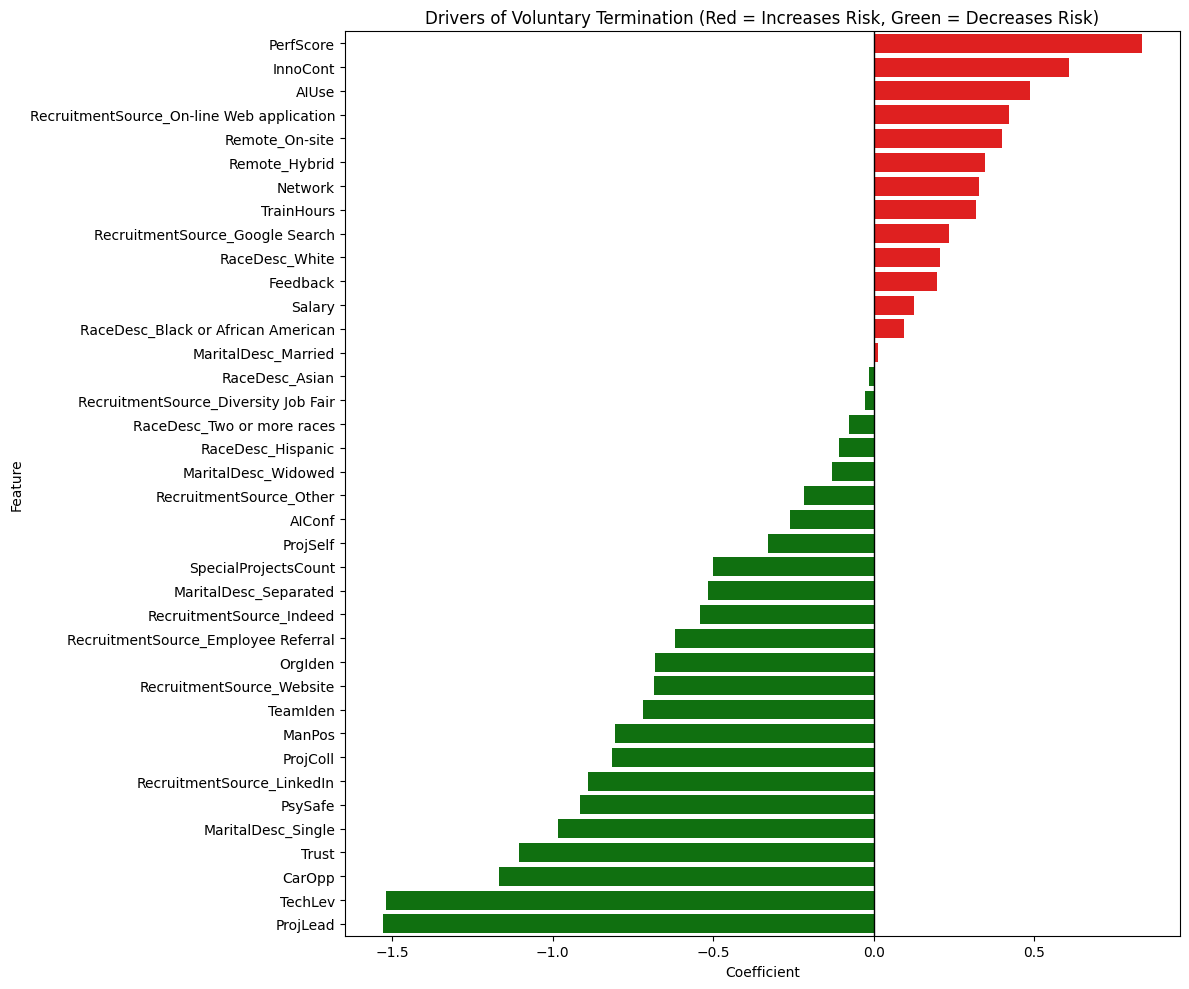

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Filter Data and Map Binary Target
# We only want Active and Voluntarily Terminated
target_map = {'Active': 0, 'Voluntarily Terminated': 1}
df_filtered = df[df['EmploymentStatus'].isin(target_map.keys())].copy()
df_filtered['Target'] = df_filtered['EmploymentStatus'].map(target_map)

# 2. Define Features
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours', 'PerfScore', 'Salary', 
    'MaritalDesc', 'RaceDesc', 'RecruitmentSource', 'Remote'
]

X = pd.get_dummies(df_filtered[features], drop_first=True)
y = df_filtered['Target']

# 3. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Build Pipeline (StandardScaler is mandatory for Logistic Regression)
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

# 5. 5-Fold Cross-Validation
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5)

# 6. Train the Model
model_pipeline.fit(X_train, y_train)

# 7. Coefficient Analysis
coefs = model_pipeline.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

# 8. Calculate Probabilities for ALL currently Active users
active_users = X[y == 0]
# Column 1 corresponds to class '1' (Voluntarily Terminated)
flight_risk_probs = model_pipeline.predict_proba(active_users)[:, 1]

# --- OUTPUTS ---

print(f"### 5-Fold CV Accuracy: {cv_scores.mean():.4f}")

print("\n### TOP PREDICTORS OF TURNOVER (Positive = Higher Risk of Leaving)")
print(importance_df.head(10))

# Displaying a few risk scores
risk_table = pd.DataFrame({
    'Employee_Index': active_users.index,
    'Flight_Risk_Probability': flight_risk_probs
}).sort_values(by='Flight_Risk_Probability', ascending=False)

print("\n### TOP 5 ACTIVE EMPLOYEES AT RISK")
print(risk_table.head(5))

# 9. Visualization
plt.figure(figsize=(12, 10))
colors = ['red' if x > 0 else 'green' for x in importance_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette=colors)
plt.title('Drivers of Voluntary Termination (Red = Increases Risk, Green = Decreases Risk)')
plt.axvline(x=0, color='black', lw=1)
plt.tight_layout()
plt.show()

### 5-FOLD CROSS-VALIDATION RESULTS (TRAIN SET)
Mean Accuracy:  0.8473
Mean Precision: 0.7171
Mean Recall:    0.8426
Mean F1-Score:  0.7706


/var/folders/b9/kg61r4ld3bldd20tdz24tnt80000gn/T/ipykernel_89877/1539438313.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette=colors)


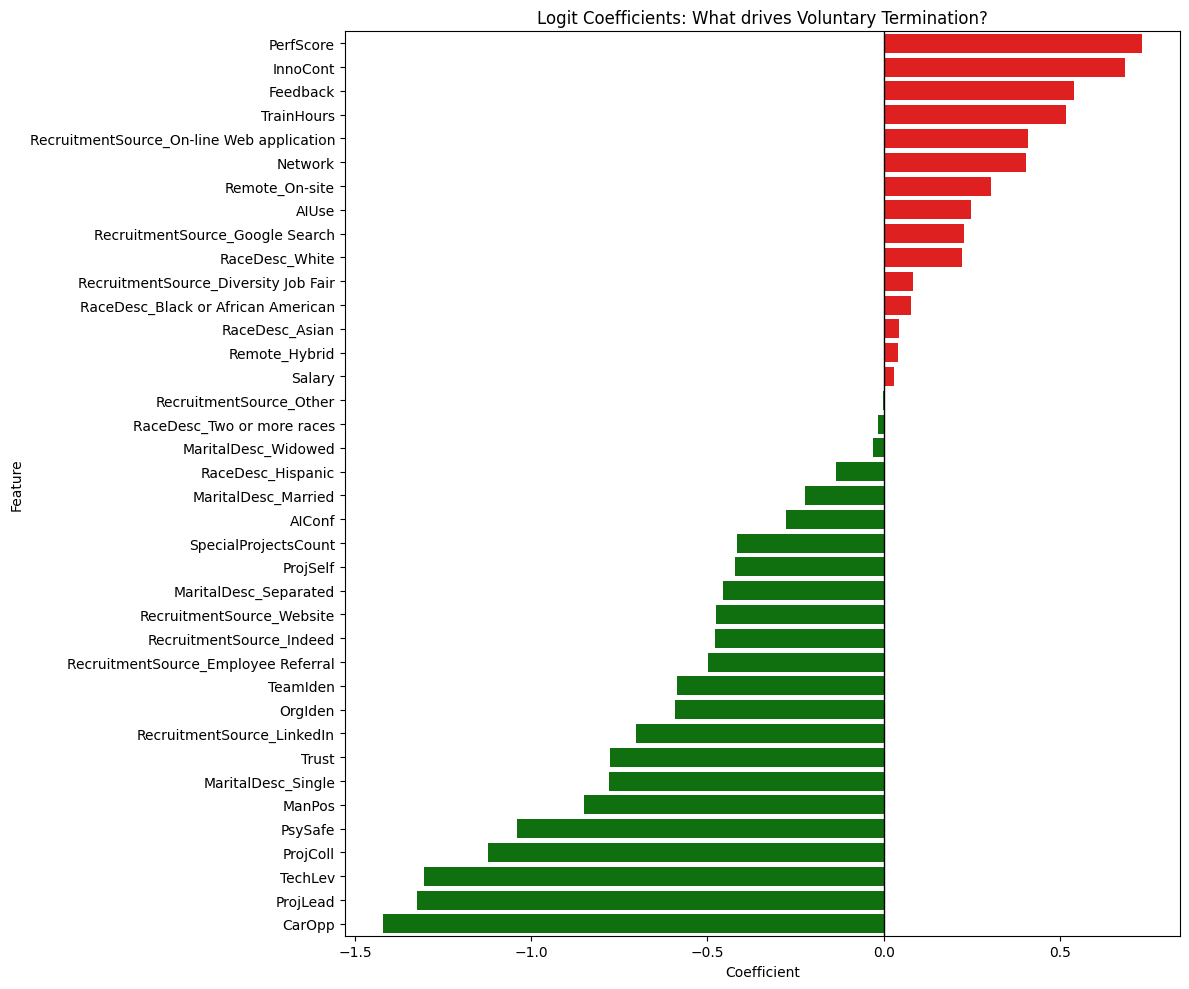


### RISK ASSESSMENT: THE 20 LEFT-OUT EMPLOYEES
             Employee_Name           Actual_Status  Leaving_Probability
247          Sadki, Nore    Voluntarily Terminated             0.984421
256       Sloan, Constance  Voluntarily Terminated             0.908976
188            Miller, Ned  Voluntarily Terminated             0.902230
218     Peterson, Ebonee    Voluntarily Terminated             0.800051
147        Kampew, Donysha  Voluntarily Terminated             0.669557
304     Winthrop, Jordan    Voluntarily Terminated             0.610154
139     Jackson, Maryellen                  Active             0.465409
165       Lecter, Hannibal                  Active             0.409136
172         Lunquist, Lisa                  Active             0.201665
98          Fraval, Maruk                   Active             0.060523
274          Szabo, Andrew                  Active             0.057758
22           Billis, Helen                  Active             0.030159
120           Gr

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Filter Data and Map Binary Target (0: Active, 1: Voluntarily Terminated)
target_map = {'Active': 0, 'Voluntarily Terminated': 1}
df_filtered = df[df['EmploymentStatus'].isin(target_map.keys())].copy()
df_filtered['Target'] = df_filtered['EmploymentStatus'].map(target_map)

# 2. Define Features
features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TechLev', 
    'ManPos', 'InnoCont', 'TrainHours', 'PerfScore', 'Salary', 
    'MaritalDesc', 'RaceDesc', 'RecruitmentSource', 'Remote'
]

X = pd.get_dummies(df_filtered[features], drop_first=True)
y = df_filtered['Target']

# 3. Leave exactly 20 people out for the test set
test_count = 20
test_ratio = test_count / len(df_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_ratio, random_state=42, stratify=y
)

# 4. Build Pipeline
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

# 5. 5-Fold Cross-Validation on Training Set (Metrics: Accuracy, Recall, Precision, F1)
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(model_pipeline, X_train, y_train, cv=5, scoring=scoring)

# 6. Train the Model on the full training set
model_pipeline.fit(X_train, y_train)

# 7. Output CV Metrics
print("### 5-FOLD CROSS-VALIDATION RESULTS (TRAIN SET)")
print(f"Mean Accuracy:  {cv_results['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Mean Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"Mean F1-Score:  {cv_results['test_f1'].mean():.4f}")

# 8. Coefficient Analysis & Visualization
coefs = model_pipeline.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(12, 10))
colors = ['red' if x > 0 else 'green' for x in importance_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette=colors)
plt.title('Logit Coefficients: What drives Voluntary Termination?')
plt.axvline(x=0, color='black', lw=1)
plt.tight_layout()
plt.show()

# 9. Apply model to the 20 left-out people
# Probability of leaving (Class 1)
test_probs = model_pipeline.predict_proba(X_test)[:, 1]

# Create final dataframe for the 20 test subjects
# We map the numeric target back to original labels for readability
risk_report_20 = pd.DataFrame({
    'Actual_Status': y_test.map({0: 'Active', 1: 'Voluntarily Terminated'}).values,
    'Leaving_Probability': test_probs
}, index=X_test.index)

# Add Employee Name if available
if 'Employee.Name' in df.columns:
    risk_report_20.insert(0, 'Employee_Name', df.loc[X_test.index, 'Employee.Name'].values)

print("\n### RISK ASSESSMENT: THE 20 LEFT-OUT EMPLOYEES")
print(risk_report_20.sort_values('Leaving_Probability', ascending=False))

# Optional: Performance on those 20 people
print("\n### CLASSIFICATION REPORT FOR THE 20 TEST EMPLOYEES")
y_test_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred))